# k NEAREST NEIGHBOURS FROM SCRATCH

In [35]:

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap=ListedColormap(['#FF0000',"#00FF00","#0000FF"])
from collections import Counter


In [36]:
def euclidean_distances(x1,x2):
    return  np.sqrt(np.sum((x1-x2)**2))

In [ ]:
class KNN:

    def __init__(self,k=3):
        self.K=k

    def fit(self,X,y) :
        self.X_train=X
        self.y_train=y

    def predict(self,X_test):
        predicted_labels=[self.__predict(x) for x in X_test]
        return np.array(predicted_labels)

    def __predict(self,x_new):
        # Compute distances
        distances=[euclidean_distances(x_new,x_train) for x_train in self.X_train]

        # get k nearest samples , labels
        k_indices=np.argsort(distances)[0:self.K]
        K_nearest_lables=[self.y_train[i] for i in k_indices]
        # majority vote , most common class label
        most_common=Counter(K_nearest_lables).most_common(1)
        return most_common[0][0]
            

In [38]:

iris=datasets.load_iris()
x,y=iris.data,iris.target

In [39]:
print(x.shape)
print(y.shape)


(150, 4)
(150,)


In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1234)

In [41]:
print(x_train.shape)
print(y_train.shape)
print(y_train)

(120, 4)
(120,)
[1 2 0 2 1 0 0 0 0 1 0 1 0 2 2 0 2 2 2 2 0 2 2 1 1 1 1 1 1 0 0 2 2 2 0 0 0
 2 1 2 2 1 0 2 0 2 0 1 1 0 1 0 2 2 2 1 0 0 2 1 1 0 1 2 1 1 1 0 0 0 1 1 0 2
 1 2 2 1 0 1 2 0 0 2 2 1 1 2 0 1 2 2 2 1 0 0 0 0 2 1 2 0 0 1 1 2 1 1 2 2 2
 0 2 0 0 2 2 1 0 0]


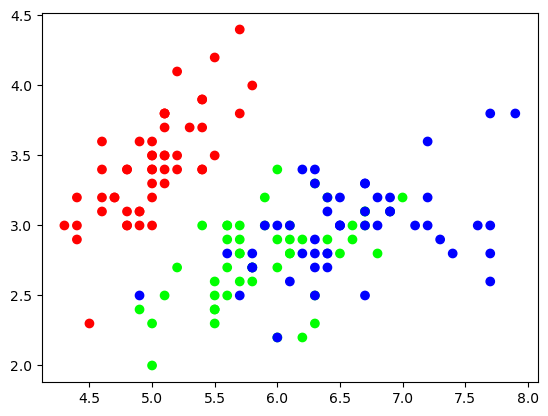

In [42]:
plt.figure()
plt.scatter(x[:,0],x[:,1],c=y,cmap=cmap)

In [43]:

clf=KNN(5)
clf.fit(x_train,y_train)
predicted_labels=clf.predict(x_test)
print(predicted_labels)

acc=np.sum(predicted_labels==y_test)/ len(y_test)
print(acc *100)
print(len(predicted_labels))

[1 2 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0]
96.66666666666667
30
